## Convert the Baysor polygon mask into a npz sparse matrix
Baysor produces a json poligon file. ISS pipeline needs an .npz file to segment the spots. 
For the conversion to proceed correctly (and to match the spots coordinates) we need to input also the final global x and y dimensions in pixels: this values can only be calculated from any of the decoded images, ie. a stitched and aligned dapi works.

Please contact Christina Bekiari for more information.

In [ ]:
import tifffile as tff

In [ ]:
dapi=tff.imread('/mnt/DATA/ext_home/christina/archive/christina/Chicken/Chicken_3rdTrial_A2.1_E3_40X/RedLionFish2/R1/preprocessing/Cycle1/3_stitched/Cycle1_ch4.tif')

In [ ]:
## define a function to CREATE A SEGMENTATION MASK NPZ from the JSON output of Baysor

import json, os
import numpy as np
from skimage.draw import polygon
from PIL import Image
from scipy import sparse

def geojson_to_sparse_mask(
    geojson_path: str,
    out_npz_path: str,
    mask_shape: tuple,        # (H, W), e.g. (21094, 17346)
    dtype=np.uint32,          # >= 65k labels possible
    save_preview=True
):
    """
    Convert GeoJSON polygons to a sparse Cellpose-style segmentation mask (.npz).
    The .npz can be loaded with scipy.sparse.load_npz.
    
    Parameters
    ----------
    geojson_path : str
        Path to input .geojson file.
    out_npz_path : str
        Output sparse .npz file.
    mask_shape : tuple
        Shape of the output mask (H, W).
    dtype : np.dtype
        np.uint16 if <=65k cells, np.uint32 or np.int32 otherwise.
    save_preview : bool
        If True, saves a PNG preview (labels modulo 256).
    """
    # --- Load polygons ---
    with open(geojson_path, "r") as f:
        geo = json.load(f)

    polys = []
    for feat in geo.get("features", []):
        geom = feat.get("geometry", {})
        if geom.get("type") == "Polygon":
            coords = geom["coordinates"][0]  # exterior ring
            polys.append(coords)
        elif geom.get("type") == "MultiPolygon":
            for poly in geom["coordinates"]:
                coords = poly[0]
                polys.append(coords)

    if not polys:
        raise ValueError("No polygons found in GeoJSON.")

    # --- Rasterize into dense mask ---
    H, W = mask_shape
    mask = np.zeros((H, W), dtype=dtype)

    label = 1
    for poly in polys:
        xs, ys = zip(*poly)
        rr, cc = polygon(ys, xs, mask.shape)
        mask[rr, cc] = label
        label += 1

    # --- Convert to sparse ---
    mask_sparse = sparse.csr_matrix(mask)

    # --- Save sparse mask ---
    sparse.save_npz(out_npz_path, mask_sparse)

    # --- Optional preview ---
    preview_path = None
    if save_preview:
        preview_path = os.path.splitext(out_npz_path)[0] + "_preview.png"
        prev = (mask % 256).astype(np.uint8)
        Image.fromarray(prev).save(preview_path)

    return {
        "masks_shape": mask.shape,
        "num_labels": int(mask.max()),
        "out_path": out_npz_path,
        "preview_png": preview_path
    }

In [ ]:
# Get the shape of your image
dapi.shape

## This is where the segmentation conversion actually happens.

You need to input the polygons, an output location and the `mask_shape` is automatically set to match the `dapi.shape`. 

In [ ]:
info = geojson_to_sparse_mask(
    "/mnt/DATA/ext_home/christina/archive/christina/Chicken/Chicken_3rdTrial_A2.1_E3_40X/RedLionFish2/R1/baysor_scale20_m4/segmentation_polygons_2d.json",
    "/mnt/DATA/ext_home/christina/archive/christina/Chicken/Chicken_3rdTrial_A2.1_E3_40X/RedLionFish2/R1/baysor_scale20_m4/R1_segmentation_mask.npz",
    mask_shape=dapi.shape,   # your image size
    dtype=np.uint32              # use np.int32 if >65k cells
)
print(info)

## Read the .npz mask back into memory

In [ ]:
coo_file = ('/mnt/DATA/ext_home/christina/archive/christina/Chicken/Chicken_3rdTrial_A2.1_E3_40X/RedLionFish2/R1/baysor_scale20_m4/R1_segmentation_mask.npz')
from scipy import sparse
import numpy as np

mask_sparse = sparse.load_npz(coo_file)  # usually CSR
coo = mask_sparse.tocoo().astype(np.int32)


In [ ]:

coo

## Overlay the segmentaion mask on the DAPI image

In [28]:
rgb_label_image = skimage.color.label2rgb(coo.toarray(), bg_label=0)

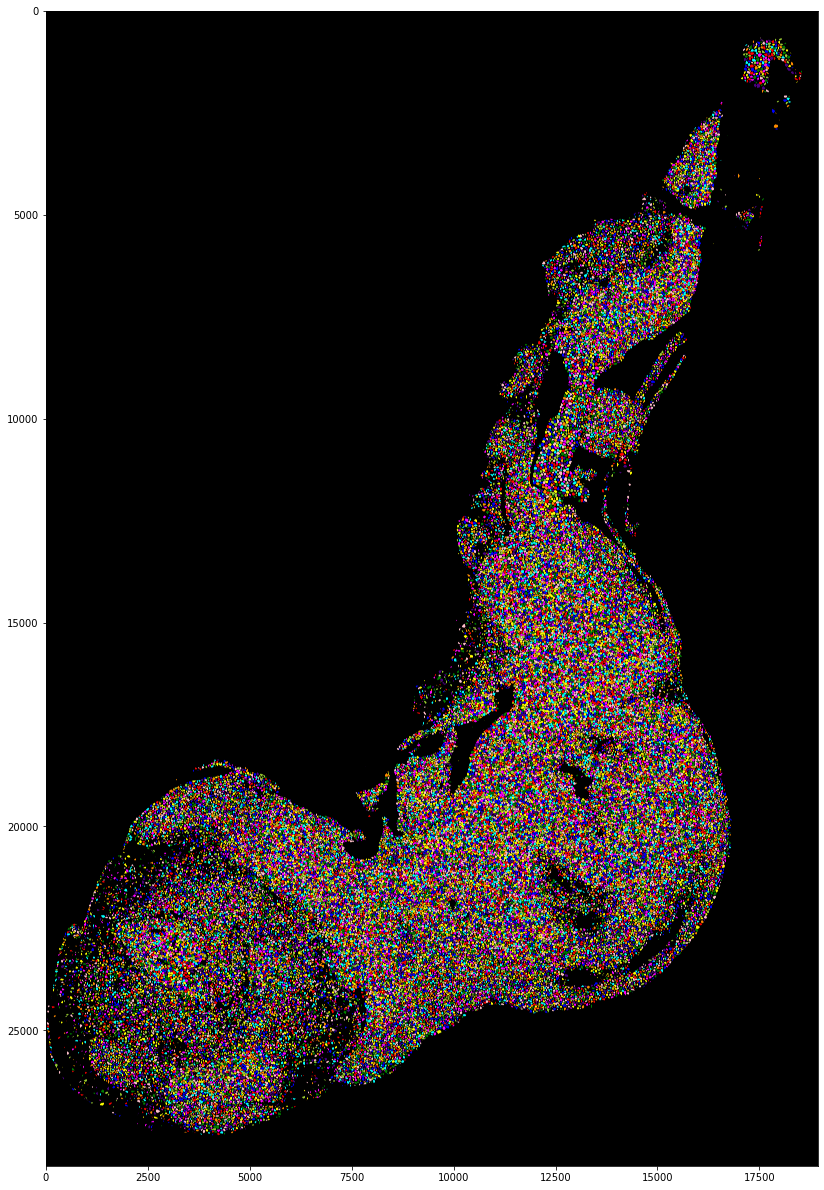

In [29]:
_dpi = 72
plt.figure(figsize=(1500/_dpi, 1500/_dpi), dpi=_dpi)
imgplot = plt.imshow(rgb_label_image)
plt.show()